# Challenge 1 — Blood Cell Classification
**MobileNetV3Large + Transfer Learning + Fine-Tuning**

## 1. Mount Google Drive

In [1]:
import os
from google.colab import drive
drive.mount('/content/drive')
base = "/content/drive/MyDrive/ANN"

print(os.listdir(base))

%cd "/content/drive/MyDrive/ANN/colloquio "

Mounted at /content/drive
['lezione 1', 'lezione 3 ', 'lezione 2', 'lesson 4 ', 'challenge', 'DACAPO', 'nuova lezione ', 'colloquio ']
/content/drive/MyDrive/ANN/colloquio 


## 2. Install Dependencies & Imports

In [2]:
!pip install -q keras-cv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 60.8 MB/s eta 0:00:00


In [3]:
import os
import random
import logging
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score,
                              precision_score, recall_score, confusion_matrix)
from sklearn.utils import shuffle

import tensorflow as tf
from tensorflow import keras as tfk
from tensorflow.keras import layers as tfkl
import keras_cv as kcv

# ── reproducibility ──────────────────────────────────────────────────────────
seed = 42
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['PYTHONHASHSEED'] = str(seed)
np.random.seed(seed)
random.seed(seed)
tf.random.set_seed(seed)
tf.autograph.set_verbosity(0)
tf.get_logger().setLevel(logging.ERROR)
logging.getLogger('tensorflow').setLevel(logging.ERROR)

print(f"TensorFlow  : {tf.__version__}")
print(f"GPU devices : {tf.config.list_physical_devices('GPU')}")

TensorFlow  : 2.20.0
GPU devices : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 3. Load Data

In [4]:
data = np.load('training_set.npz')
X = data['images']
y = data['labels']

classes     = {0:'Basophil', 1:'Eosinophil', 2:'Erythroblast',
               3:'Immature Granulocytes', 4:'Lymphocyte',
               5:'Monocyte', 6:'Neutrophil', 7:'Platelet'}
nomi_labels = list(classes.values())

print(f"Dataset shape : {X.shape}")
print(f"Labels shape  : {y.shape}")

Dataset shape : (13759, 96, 96, 3)
Labels shape  : (13759, 1)


## 4. Visualise Sample Images

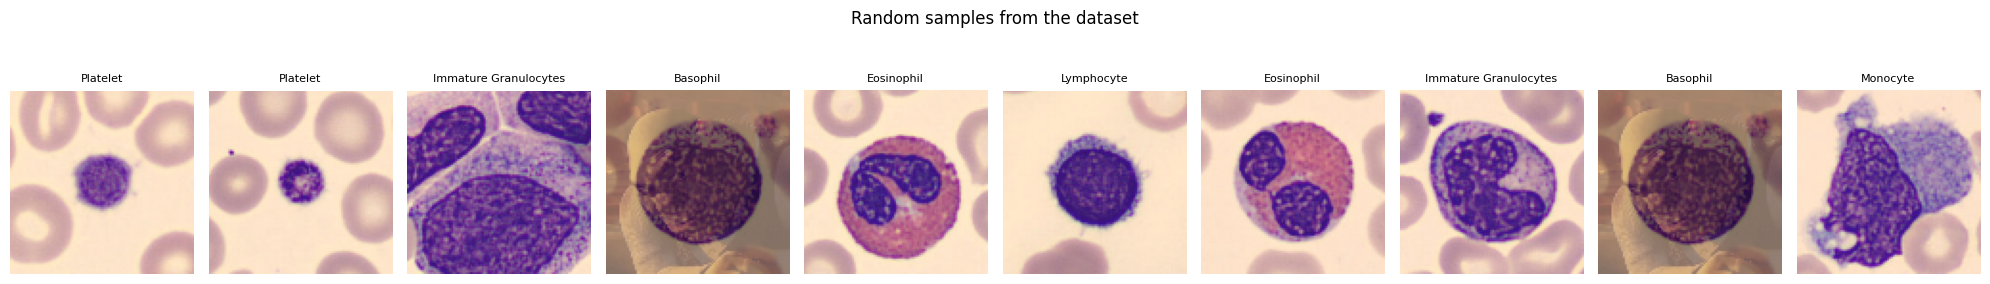

In [5]:
num_img = 10
idxs    = random.sample(range(len(X)), num_img)

fig, axes = plt.subplots(1, num_img, figsize=(20, 3))
for ax, idx in zip(axes, idxs):
    ax.imshow(np.clip(X[idx], 0, 255).astype(np.uint8))
    ax.set_title(classes[int(y[idx])], fontsize=8)
    ax.axis('off')
plt.suptitle("Random samples from the dataset", y=1.02)
plt.tight_layout()
plt.show()

## 5. Dataset Cleaning
Remove the two non-medical outlier images (frames accidentally included in the dataset).

In [6]:
# The two outlier images are at fixed indices 13000 and 13753
outlier_a = X[13000]
outlier_b = X[13753]

to_remove = [i for i, img in enumerate(X)
             if np.array_equal(img, outlier_a) or np.array_equal(img, outlier_b)]

X = np.delete(X, to_remove, axis=0)
y = np.delete(y, to_remove, axis=0)

print(f"Removed {len(to_remove)} outlier images")
print(f"Clean dataset shape: {X.shape}")

Removed 1800 outlier images
Clean dataset shape: (11959, 96, 96, 3)


## 6. Class Distribution

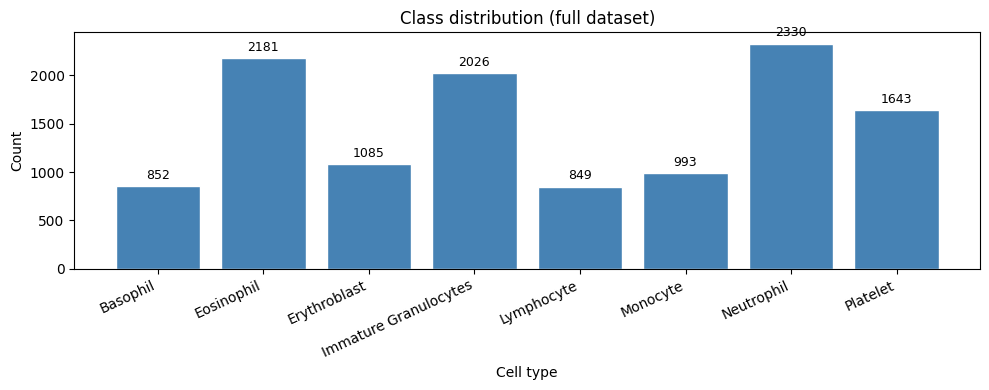

In [7]:
unique, counts = np.unique(y, return_counts=True)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(nomi_labels, counts, color='steelblue', edgecolor='white')
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_title("Class distribution (full dataset)")
ax.set_ylabel("Count")
ax.set_xlabel("Cell type")
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

## 7. Train / Validation / Test Split

In [8]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=1000, random_state=seed, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=2000, random_state=seed, stratify=y_train_val
)

print(f"Train : {X_train.shape[0]:>6,} images")
print(f"Val   : {X_val.shape[0]:>6,} images")
print(f"Test  : {X_test.shape[0]:>6,} images")

Train :  8,959 images
Val   :  2,000 images
Test  :  1,000 images


## 8. Class Balancing (Oversampling + Augmentation)

Every class is brought to **2 500 samples** via augmented copies of minority classes.
The three hardest classes (3, 5, 6) receive an extra round of **CutMix** augmentation.

In [9]:
# ── offline augmentation pipeline ────────────────────────────────────────────
augmentation = tf.keras.Sequential([
    tfkl.RandomTranslation(0.2, 0.2, fill_mode='nearest'),
    tfkl.RandomRotation(0.8),
    kcv.layers.RandomSharpness(factor=1.0, value_range=(0, 1)),
    tfkl.RandomFlip(mode='horizontal_and_vertical'),
])

TARGET = 2500
_, count_train = np.unique(y_train, return_counts=True)

for cls in range(8):
    n_missing = TARGET - count_train[cls]
    if n_missing <= 0:
        continue
    idxs   = np.where(y_train == cls)[0]
    chosen = np.array(random.choices(X_train[idxs], k=n_missing))
    augm   = np.clip(augmentation(chosen / 255.0) * 255.0, 0, 255)
    labels = np.full((n_missing, 1), cls)
    X_train = np.concatenate([X_train, augm], axis=0)
    y_train = np.concatenate([y_train, labels], axis=0)

X_train, y_train = shuffle(X_train, y_train, random_state=seed)

# Augment val for the 3 hardest classes to get more stable estimates
for cls in [3, 5, 6]:
    idxs   = np.where(y_val == cls)[0]
    chosen = np.array(random.choices(X_val[idxs], k=300))
    augm   = np.clip(augmentation(chosen / 255.0) * 255.0, 0, 255)
    labels = np.full((300, 1), cls)
    X_val  = np.concatenate([X_val, augm], axis=0)
    y_val  = np.concatenate([y_val, labels], axis=0)

X_val, y_val = shuffle(X_val, y_val, random_state=seed)
print(f"Train after balancing : {X_train.shape[0]:,}")
print(f"Val   after balancing : {X_val.shape[0]:,}")

Train after balancing : 20,000
Val   after balancing : 2,900


In [10]:
# ── CutMix for the 3 hardest classes ─────────────────────────────────────────
y_train_oh = tfk.utils.to_categorical(y_train, 8).astype(np.float32)
cut_mix_layer = kcv.layers.CutMix(alpha=1.0, seed=seed)

for cls in [3, 5, 6]:
    idxs   = np.where(y_train_oh[:, cls] == 1.0)[0].tolist()
    chosen = random.sample(idxs, k=min(1500, len(idxs)))
    X_sel  = tf.convert_to_tensor(X_train[chosen])
    y_sel  = tf.convert_to_tensor(y_train_oh[chosen])
    X_aug, y_aug = cut_mix_layer({"images": X_sel, "labels": y_sel}).values()
    X_train = np.concatenate([X_train, X_aug.numpy()], axis=0)
    y_train_oh = np.concatenate([y_train_oh, y_aug.numpy()], axis=0)

# sync integer labels (argmax) for potential re-use
y_train = np.argmax(y_train_oh, axis=1, keepdims=True)
X_train, y_train_oh = shuffle(X_train, y_train_oh, random_state=seed)
y_train, _ = shuffle(y_train, y_train_oh, random_state=seed)   # keep in sync

# one-hot encode val and test
y_val_oh  = tfk.utils.to_categorical(y_val,  8).astype(np.float32)
y_test_oh = tfk.utils.to_categorical(y_test, 8).astype(np.float32)

print(f"Final train size : {X_train.shape[0]:,}")

Final train size : 24,500


## 9. tf.data Pipeline with Online Augmentation

In [11]:
BATCH_SIZE = 32

rand_augment  = kcv.layers.RandAugment(
    value_range=(0, 255), augmentations_per_image=2,
    magnitude=0.4, magnitude_stddev=0.15, rate=0.8,
    geometric=True, seed=seed,
)
flip_layer     = tfkl.RandomFlip()
rotation_layer = tfkl.RandomRotation(factor=0.5)

def augment_batch(image, label):
    image = rand_augment(image)
    image = flip_layer(image)
    image = rotation_layer(image)
    return image, label

train_ds = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train_oh))
    .shuffle(1000, seed=seed)
    .batch(BATCH_SIZE)
    .map(augment_batch, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((X_val, y_val_oh))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("Datasets ready.")

Datasets ready.


## 10. Model Definition

**Phase 1 — Feature extraction:** backbone frozen, only the custom head is trained.

**Phase 2 — Fine-tuning:** the last Conv2D / DepthwiseConv2D layers of the backbone are unlocked.

In [12]:
input_shape  = X_train.shape[1:]   # (96, 96, 3)
output_shape = 8

# ── build frozen backbone ────────────────────────────────────────────────────
mobilenet = tfk.applications.MobileNetV3Large(
    input_shape=(96, 96, 3),
    dropout_rate=0.01,
    include_top=False,
    weights='imagenet',
    pooling='max',
)
mobilenet.trainable = False

def build_model(l2_lambda=5e-3, learning_rate=1e-3, use_lion=True):
    regulariser = tfk.regularizers.l2(l2_lambda)

    inputs = tfk.Input(input_shape, name='input')

    # lightweight online augmentation inside the model (active only at train time)
    x = tf.keras.Sequential([
        tfkl.RandomFlip('horizontal and vertical'),
        tfkl.RandomTranslation(0.2, 0.2),
        tfkl.RandomRotation(0.5),
    ], name='aug')(inputs)

    x = mobilenet(x)
    x = tfkl.Dense(128, name='dense')(x)
    x = tfkl.ReLU(name='relu')(x)
    outputs = tfkl.Dense(output_shape, activation='softmax',
                         kernel_regularizer=regulariser, name='output')(x)

    model = tfk.Model(inputs, outputs, name='BloodCell_MobileNetV3L')

    if use_lion:
        opt = tfk.optimizers.Lion(learning_rate / 10)
    else:
        opt = tfk.optimizers.Adam(learning_rate)

    model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])
    return model

model = build_model()
model.summary(expand_nested=False)

12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "BloodCell_MobileNetV3L"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ aug (Sequential)                │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Large (Functional)   │ (None, 960)            │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       123,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu (ReLU)                     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,120,392 (11.90 MB)

 Trainable params: 124,040 (484.53 KB)

 Non-trainable params: 2,996,352 (11.43 MB)

## 11. Phase 1 — Train Head (Backbone Frozen)

In [13]:
EPOCHS = 300

es = tfk.callbacks.EarlyStopping(
    monitor='val_accuracy', mode='max',
    patience=10, restore_best_weights=True, verbose=1
)
rlr = tfk.callbacks.ReduceLROnPlateau(
    monitor='val_accuracy', mode='max',
    factor=0.1, patience=7, min_delta=0.0015, min_lr=1e-5, verbose=0
)

history1 = model.fit(
    train_ds, epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=[es, rlr], verbose=0
).history

best_val_acc = round(max(history1['val_accuracy']) * 100, 2)
print(f"\nBest val accuracy (phase 1): {best_val_acc}%")
model.save('phase1_model.keras')

Epoch 39: early stopping
Restoring model weights from the end of the best epoch: 29.

Best val accuracy (phase 1): 89.83%


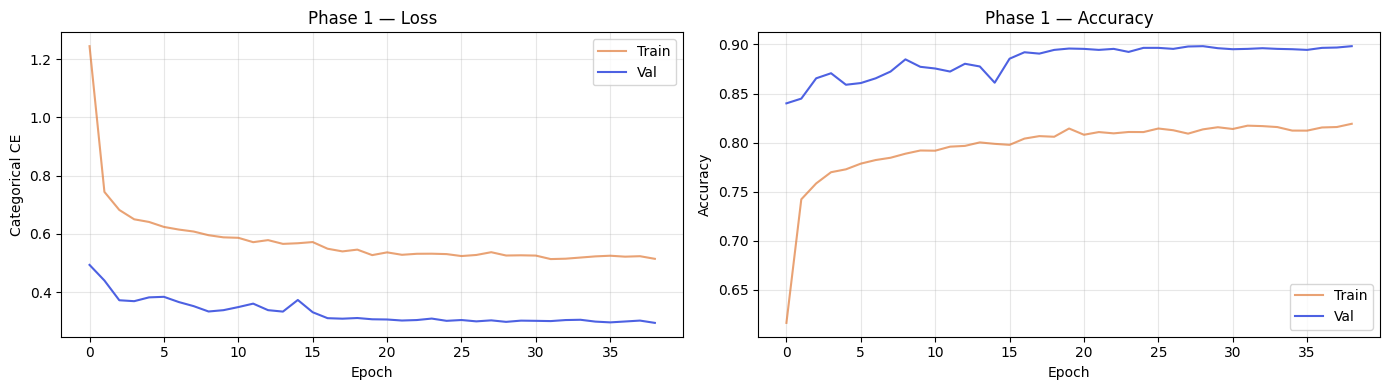

In [14]:
# ── training curves ──────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(history1['loss'],     label='Train', color='#E07B39', alpha=0.7)
ax1.plot(history1['val_loss'], label='Val',   color='#4D61E2')
ax1.set_title('Phase 1 — Loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Categorical CE')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(history1['accuracy'],     label='Train', color='#E07B39', alpha=0.7)
ax2.plot(history1['val_accuracy'], label='Val',   color='#4D61E2')
ax2.set_title('Phase 1 — Accuracy')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 12. Phase 2 — Fine-Tuning (Selective Unfreeze)

In [15]:
# reload best phase-1 weights
model = tfk.models.load_model('phase1_model.keras')

# unfreeze Conv2D / DepthwiseConv2D in the last N layers
N_FREEZE = 124
backbone = model.get_layer('MobileNetV3Large')
backbone.trainable = True

for layer in backbone.layers[:N_FREEZE]:
    layer.trainable = False

for layer in backbone.layers:
    if not isinstance(layer, (tf.keras.layers.Conv2D,
                               tf.keras.layers.DepthwiseConv2D)):
        layer.trainable = False

trainable_params = sum(np.prod(v.shape) for v in model.trainable_variables)
print(f"Trainable parameters: {trainable_params:,}")

model.compile(
    loss='categorical_crossentropy',
    optimizer=tfk.optimizers.Adam(5e-5),
    metrics=['accuracy']
)

Trainable parameters: 2,673,464


In [ ]:
es2 = tfk.callbacks.EarlyStopping(
    monitor='val_accuracy', mode='max',
    patience=11, restore_best_weights=True, verbose=1
)
rlr2 = tfk.callbacks.ReduceLROnPlateau(
    monitor='val_accuracy', mode='max',
    factor=0.25, patience=7, min_delta=0.0015, min_lr=5e-6, verbose=0
)

history2 = model.fit(
    train_ds, epochs=100,
    validation_data=val_ds,
    callbacks=[es2, rlr2], verbose=1
).history

best_val_acc2 = round(max(history2['val_accuracy']) * 100, 2)
print(f"\nBest val accuracy (phase 2): {best_val_acc2}%")
model.save(f'BloodCell_MobileNetV3L_{best_val_acc2}.keras')

766/766 ━━━━━━━━━━━━━━━━━━━━ 145s 188ms/step - accuracy: 0.8773 - loss: 0.3490 - val_accuracy: 0.9379 - val_loss: 0.1831 - learning_rate: 5.0000e-05
Epoch 3/100
766/766 ━━━━━━━━━━━━━━━━━━━━ 200s 186ms/step - accuracy: 0.8935 - loss: 0.3086 - val_accuracy: 0.9514 - val_loss: 0.1490 - learning_rate: 5.0000e-05
Epoch 4/100
766/766 ━━━━━━━━━━━━━━━━━━━━ 144s 186ms/step - accuracy: 0.9000 - loss: 0.2901 - val_accuracy: 0.9607 - val_loss: 0.1243 - learning_rate: 5.0000e-05
Epoch 5/100
766/766 ━━━━━━━━━━━━━━━━━━━━ 142s 184ms/step - accuracy: 0.9104 - loss: 0.2610 - val_accuracy: 0.9600 - val_loss: 0.1242 - learning_rate: 5.0000e-05
Epoch 6/100
766/766 ━━━━━━━━━━━━━━━━━━━━ 143s 185ms/step - accuracy: 0.9094 - loss: 0.2629 - val_accuracy: 0.9638 - val_loss: 0.1087 - learning_rate: 5.0000e-05
Epoch 7/100
766/766 ━━━━━━━━━━━━━━━━━━━━ 142s 184ms/step - accuracy: 0.9162 - loss: 0.2450 - val_accuracy: 0.9676 - val_loss: 0.1063 - learning_rate: 5.0000e-05
Epoch 8/100
766/766 ━━━━━━━━━━━━━━━━━━━━ 145s 

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(history2['loss'],     label='Train', color='#E07B39', alpha=0.7)
ax1.plot(history2['val_loss'], label='Val',   color='#4D61E2')
ax1.set_title('Phase 2 — Loss (Fine-Tuning)')
ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(history2['accuracy'],     label='Train', color='#E07B39', alpha=0.7)
ax2.plot(history2['val_accuracy'], label='Val',   color='#4D61E2')
ax2.set_title('Phase 2 — Accuracy (Fine-Tuning)')
ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 13. Evaluation on Test Set (with TTA)

In [ ]:
# ── Test-Time Augmentation ───────────────────────────────────────────────────
tta_aug = tfk.Sequential([
    tfkl.RandomFlip('horizontal_and_vertical'),
    tfkl.RandomRotation(0.5),
    tfkl.RandomContrast(0.35),
    tfkl.RandomTranslation(0.2, 0.2),
])

N_TTA   = 5
X_norm  = X_test / 255.0

preds_all = model.predict(X_test, verbose=0)[np.newaxis, ...]
for _ in range(N_TTA):
    X_aug = tta_aug(X_norm).numpy() * 255.0
    p     = model.predict(X_aug, verbose=0)[np.newaxis, ...]
    preds_all = np.concatenate([preds_all, p], axis=0)

mean_preds = preds_all.mean(axis=0)
y_pred     = np.argmax(mean_preds, axis=1)
y_true     = np.argmax(y_test_oh, axis=1)

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")

In [ ]:
# ── Confusion Matrix ─────────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=nomi_labels, yticklabels=nomi_labels, ax=ax)
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_title('Confusion Matrix — Test Set (with TTA)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# ── Per-class F1 ─────────────────────────────────────────────────────────────
per_class_f1 = f1_score(y_true, y_pred, average=None, zero_division=0)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(nomi_labels, per_class_f1, color='steelblue', edgecolor='white')
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
ax.set_ylim(0, 1.08)
ax.set_ylabel('F1 Score')
ax.set_title('Per-class F1 Score — Test Set')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

## 14. Prepare Submission

Write `model.py` and zip it with the saved `.keras` file.

In [ ]:
model_file = f'BloodCell_MobileNetV3L_{best_val_acc2}.keras'

model_py = f"""import numpy as np
import tensorflow as tf
from tensorflow import keras as tfk
from tensorflow.keras import layers as tfkl


class Model:
    def __init__(self):
        self.net = tfk.models.load_model('{model_file}')
        self.aug = tfk.Sequential([
            tfkl.RandomFlip('horizontal_and_vertical'),
            tfkl.RandomRotation(0.5),
            tfkl.RandomContrast(0.35),
            tfkl.RandomTranslation(0.2, 0.2),
        ])

    def predict(self, X):
        X_norm = X / 255.0
        preds  = self.net.predict(X, verbose=0)[np.newaxis, ...]
        for _ in range(5):
            X_aug = self.aug(X_norm).numpy() * 255.0
            p     = self.net.predict(X_aug, verbose=0)[np.newaxis, ...]
            preds = np.concatenate([preds, p], axis=0)
        return np.argmax(preds.mean(axis=0), axis=1)
"""

with open('model.py', 'w') as f:
    f.write(model_py)

from datetime import datetime
zip_name = f'submission_{datetime.now().strftime("%y%m%d_%H%M%S")}.zip'
import subprocess
subprocess.run(['zip', zip_name, 'model.py', model_file], check=True)
print(f"Saved: {zip_name}")

In [ ]:
from google.colab import files
files.download(zip_name)